# 광고 성과 데이터 분석

## 분석 목적

광고 대행사의 시간대·매체·광고별 성과를 분석하여
클릭과 전환 효율이 높은 영역과 비효율적인 영역을 파악한다.

## 분석 질문

1. 클릭과 전환이 가장 많이 발생하는 시간대는 언제인가?
2. 전환 성과가 좋은 매체는 어디인가?
3. 충분한 트래픽을 확보하면서 CVR이 높은 매체는 어디인가?
4. 성과가 좋은 광고와 좋지 않은 광고의 차이는 무엇인가?
5. 광고 비용 및 수익 측면에서 비효율적인 광고는 존재하는가?

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel(r"D:\실제_데이터_및_실습_코드_통합본\real_data_sheet1.xlsx")

In [3]:
df.head()

,rpt_time_date,rpt_time_time,ads_idx,mda_idx,rpt_time_clk,rpt_time_turn,rpt_time_scost,rpt_time_acost,rpt_time_cost,rpt_time_earn
0,2024-07-27,0,4418,761,1,0,0,0,0,0
1,2024-07-27,0,7377,213,1,0,0,0,0,0
2,2024-07-27,0,7377,337,1,0,0,0,0,0
3,2024-07-27,0,7377,496,1,1,230,230,180,180
4,2024-07-27,0,7528,792,1,0,0,0,0,0


In [5]:
df.shape

(1048575, 10)

In [6]:
df.columns

Index(['rpt_time_date', 'rpt_time_time', 'ads_idx', 'mda_idx', 'rpt_time_clk',
       'rpt_time_turn', 'rpt_time_scost', 'rpt_time_acost', 'rpt_time_cost',
       'rpt_time_earn'],
      dtype='str')

In [7]:
df.dtypes

rpt_time_date       str
rpt_time_time     int64
ads_idx           int64
mda_idx           int64
rpt_time_clk      int64
rpt_time_turn     int64
rpt_time_scost    int64
rpt_time_acost    int64
rpt_time_cost     int64
rpt_time_earn     int64
dtype: object

In [8]:
df.isnull().sum()

rpt_time_date     0
rpt_time_time     0
ads_idx           0
mda_idx           0
rpt_time_clk      0
rpt_time_turn     0
rpt_time_scost    0
rpt_time_acost    0
rpt_time_cost     0
rpt_time_earn     0
dtype: int64

In [9]:
#날짜/시간간 처리하기


#날짜

df['rpt_time_date'] = pd.to_datetime(df['rpt_time_date'])

#시간

df['hour'] = pd.to_numeric(df['rpt_time_time'])

In [ ]:
#시간대 분석

hour_click = df.groupby('hour')['rpt_time_clk'].sum()

hour_click



hour
0     810900
1     666575
2     401476
3     293188
4     269727
5     305282
6     413623
7     478774
8     464593
9     426388
10    453913
11    430280
12    431163
13    461083
14    469197
15    486952
16    475741
17    450966
18    410104
19    396154
20    377387
21    359228
22    347062
23    291630
Name: rpt_time_clk, dtype: int64

### 해석

- 0시의 클릭수가 다른 시간대에 비해 매우 높게 나타났다.
- 새벽 2~5시에는 클릭량이 크게 감소한다.
- 낮 시간대에는 비교적 일정한 클릭량이 유지된다.
- 단순 클릭수만으로 광고 효율을 판단할 수 없으므로,
  이후 시간대별 전환수와 CVR을 함께 비교한다.

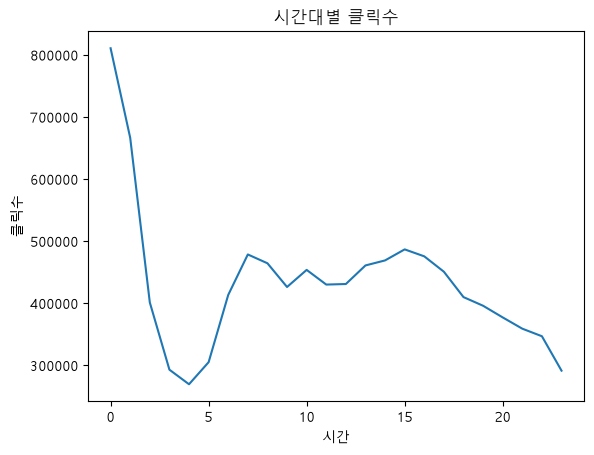

In [ ]:
#그래프

hour_click.plot()

plt.title('시간대별 클릭수')
plt.xlabel('시간')
plt.ylabel('클릭수')
plt.show()

In [32]:
#전환도

# 시간 컬럼 만들기
df['hour'] = pd.to_numeric(df['rpt_time_time'])

hour_turn = df.groupby('hour')['rpt_time_turn'].sum()

hour_turn


hour
0     406948
1     365801
2     211422
3     146314
4     131181
5     153981
6     218698
7     257439
8     246836
9     217250
10    235465
11    217897
12    211440
13    239282
14    248351
15    257915
16    249909
17    232865
18    211941
19    201375
20    190832
21    175065
22    160389
23    131935
Name: rpt_time_turn, dtype: int64

In [33]:
#매체별 성과 분석

media = df.groupby('mda_idx')[['rpt_time_clk','rpt_time_turn']].sum()


media['CVR'] = media['rpt_time_turn'] / media['rpt_time_clk']

media

,rpt_time_clk,rpt_time_turn,CVR
mda_idx,,,
12,242399,98021,0.404379
14,410416,93611,0.228088
18,51613,17251,0.334237
22,50844,17356,0.341358
26,15809,9471,0.599089
...,...,...,...
827,6,5,0.833333
828,1,1,1.000000
829,311,6,0.019293


In [25]:
#전환수가 많은 매체

media.sort_values('rpt_time_turn',ascending=False).head(10)

,rpt_time_clk,rpt_time_turn,CVR
mda_idx,,,
563,3488398,2302902,0.660160
58,846730,369991,0.436965
667,557956,297875,0.533868
343,543995,268786,0.494096
396,440673,268678,0.609699
371,417425,262937,0.629902
342,544327,252759,0.464351
562,170018,132520,0.779447
12,242399,98021,0.404379


In [26]:
#cvr이 높은 매체

media.sort_values('CVR',ascending=False).head(10)

,rpt_time_clk,rpt_time_turn,CVR
mda_idx,,,
179,1,1,1.000000
844,3,3,1.000000
826,1,1,1.000000
828,1,1,1.000000
845,789,696,0.882129
568,10636,8951,0.841576
827,6,5,0.833333
824,17710,14403,0.813269
108,15202,12349,0.812327


In [28]:
#광고별 분석

ads = df.groupby('ads_idx')[['rpt_time_clk','rpt_time_turn']].sum()

ads

,rpt_time_clk,rpt_time_turn
ads_idx,,
2595,36,4
3191,82,2
4418,297,0
6508,8,0
6667,19240,4391
...,...,...
94216,1,0
94217,1,0
94218,9,8


In [30]:
ads['CVR'] = ads['rpt_time_turn'] / ads['rpt_time_clk']

ads.sort_values('rpt_time_turn',ascending=False).head(10)

,rpt_time_clk,rpt_time_turn,CVS,CVR
ads_idx,,,,
91172,561314,324346,0.577833,0.577833
79860,380182,146960,0.386552,0.386552
91173,269858,142806,0.529189,0.529189
87012,218843,130139,0.594668,0.594668
85140,233014,130026,0.558018,0.558018
25342,232744,126056,0.541608,0.541608
79862,168623,91051,0.539968,0.539968
87013,159840,85787,0.536705,0.536705
76483,119282,70207,0.588580,0.588580
